<a href="https://colab.research.google.com/github/DikshyaL/DL-practical-lab/blob/main/COMP488P2_Dikshya.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Assignment 2: Neural Network Classification using NumPy (MLP on Fashion-MNIST)**
- Name: Dikshya Lamichhane  
- Course: COMP 488 - Neural Network and Deep Learning  
- Date: April 05, 2026  
- Tools Used: NumPy, scikit-learn, Matplotlib  
- Dataset: Fashion-MNIST (OpenML)

## Objective

- To implement a Multilayer Perceptron (MLP) from scratch using NumPy  
- To understand forward propagation, loss calculation, and backpropagation  
- To study the effect of different activation functions  
- To analyze how learning rate affects training and convergence  
- To evaluate model performance using accuracy and loss

## Theoretical Background

A Multilayer Perceptron (MLP) is a type of neural network made of layers of neurons. It has an input layer, one or more hidden layers, and an output layer.

In this assignment, we use:
- Input layer: 784 features (28x28 images)
- One hidden layer: 128 neurons
- Output layer: 10 classes

### Forward Propagation
In forward propagation, input data moves through the network:
- First, input is multiplied with weights and bias is added
- Then an activation function is applied
- Finally, output is passed through softmax to get probabilities

### Activation Functions
- ReLU: Outputs max(0, x). Fast and commonly used  
- Sigmoid: Outputs values between 0 and 1, but can cause vanishing gradient  
- Tanh: Outputs values between -1 and 1, better than sigmoid but slower than ReLU  

### Softmax
Softmax converts output values into probabilities. The sum of probabilities is 1.

### Loss Function
We use Cross-Entropy Loss to measure how far predictions are from true labels.

### Backpropagation
Backpropagation calculates gradients of loss with respect to weights.  
Weights are updated using gradient descent to reduce the loss.

### Learning Rate
Learning rate controls how big the update step is:
- Small value → slow learning  
- Large value → unstable learning, but may also speed up convergence depending on the model

## Dataset Description

The Fashion-MNIST dataset is used in this assignment. It contains grayscale images of clothing items.

- Total samples: 70,000  
- Image size: 28 x 28 pixels (flattened to 784 features)  
- Number of classes: 10  

The dataset is loaded using OpenML.

### Preprocessing Steps
- Data is normalized using StandardScaler  
- Labels are converted into one-hot encoded format  

### Train-Test Split
- 80% training data  
- 20% testing data  
- Random state is fixed for reproducibility

## Implementation

The MLP is implemented from scratch using NumPy.

### Model Structure
- Input layer: 784 neurons  
- Hidden layer: 128 neurons  
- Output layer: 10 neurons  

### Key Components
- Activation functions: ReLU, Sigmoid, Tanh  
- Softmax for output layer  
- Cross-entropy loss function  

### Training Process
Each training step includes:
1. Forward pass to compute predictions  
2. Loss calculation using cross-entropy  
3. Backward pass to compute gradients  
4. Updating weights using gradient descent  

The model is trained for multiple epochs and loss is recorded at each step.

## Experiments

Two main experiments are performed to understand model behavior.


In [ ]:
# import
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

In [ ]:
# Load Dataset
print("Loading dataset...")

dataset = fetch_openml('Fashion-MNIST', version=1, as_frame=False)

X = dataset.data
y = dataset.target

y = y.astype(np.int32)
scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# One-hot encoding
encoder = OneHotEncoder(sparse_output=False)
y_train = encoder.fit_transform(y_train.reshape(-1, 1))
y_test = encoder.transform(y_test.reshape(-1, 1))

print("Data loaded successfully.")


Loading dataset...
Data loaded successfully.


In [ ]:
# Activation functions
# ReLU
def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)
# Sigmoid
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(z):
    s = sigmoid(z)
    return s * (1 - s)
# Tanh
def tanh(z):
    return np.tanh(z)

def tanh_derivative(z):
    return 1 - np.tanh(z) ** 2

In [ ]:
# Softmax and Loss
def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def cross_entropy(y_true, y_pred):
    m = y_true.shape[0]
    return -np.sum(y_true * np.log(y_pred + 1e-9)) / m

In [ ]:
# MLP Class
class MLP:
    def __init__(self, input_size, hidden_size, output_size, activation="relu"):
        self.W1 = np.random.randn(input_size, hidden_size) * 0.01
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.randn(hidden_size, output_size) * 0.01
        self.b2 = np.zeros((1, output_size))

        if activation == "relu":
            self.act = relu
            self.act_der = relu_derivative
        elif activation == "sigmoid":
            self.act = sigmoid
            self.act_der = sigmoid_derivative
        elif activation == "tanh":
            self.act = tanh
            self.act_der = tanh_derivative

    def forward(self, X):
        self.Z1 = np.dot(X, self.W1) + self.b1
        self.A1 = self.act(self.Z1)

        self.Z2 = np.dot(self.A1, self.W2) + self.b2
        self.A2 = softmax(self.Z2)

        return self.A2

    def backward(self, X, y, output, lr):
        m = X.shape[0]

        dZ2 = output - y
        dW2 = np.dot(self.A1.T, dZ2) / m
        db2 = np.sum(dZ2, axis=0, keepdims=True) / m

        dA1 = np.dot(dZ2, self.W2.T)
        dZ1 = dA1 * self.act_der(self.Z1)

        dW1 = np.dot(X.T, dZ1) / m
        db1 = np.sum(dZ1, axis=0, keepdims=True) / m

        self.W1 -= lr * dW1
        self.b1 -= lr * db1
        self.W2 -= lr * dW2
        self.b2 -= lr * db2

In [ ]:
# Training loop
def train(X_train, y_train, activation="relu", lr=0.01, epochs=20):
    model = MLP(784, 128, 10, activation)

    losses = []
    train_accs = []
    test_accs = []

    for epoch in range(epochs):
        output = model.forward(X_train)
        loss = cross_entropy(y_train, output)
        losses.append(loss)

        model.backward(X_train, y_train, output, lr)

        # Track accuracy
        train_acc = accuracy(model, X_train, y_train)
        test_acc = accuracy(model, X_test, y_test)

        train_accs.append(train_acc)
        test_accs.append(test_acc)

        print(f"{activation} | lr={lr} | epoch={epoch+1} | loss={loss:.4f}")

    return model, losses, train_accs, test_accs

In [ ]:
# Accuracy function
def accuracy(model, X, y):
    preds = model.forward(X)
    preds = np.argmax(preds, axis=1)
    labels = np.argmax(y, axis=1)
    return np.mean(preds == labels)

### Experiment 1: Activation Functions
The model is trained using three different activation functions:
- ReLU  
- Sigmoid  
- Tanh  

Each model is trained with:
- Same learning rate (0.01)  
- Same number of epochs (20)  

The goal is to compare how activation functions affect:
- Loss reduction  
- Final accuracy  



In [ ]:
# Train for all activation learning an d comparing
activations = ["relu", "sigmoid", "tanh"]
results_act = {}

for act in activations:
    model, losses, train_accs, test_accs = train(
        X_train, y_train, activation=act, lr=0.01, epochs=20
    )

    final_acc = accuracy(model, X_test, y_test)

    results_act[act] = (losses, train_accs, test_accs, final_acc)

    print(f"{act} final accuracy: {final_acc:.4f}")

relu | lr=0.01 | epoch=1 | loss=2.3020
relu | lr=0.01 | epoch=2 | loss=2.3002
relu | lr=0.01 | epoch=3 | loss=2.2983
relu | lr=0.01 | epoch=4 | loss=2.2965
relu | lr=0.01 | epoch=5 | loss=2.2947
relu | lr=0.01 | epoch=6 | loss=2.2928
relu | lr=0.01 | epoch=7 | loss=2.2910
relu | lr=0.01 | epoch=8 | loss=2.2892
relu | lr=0.01 | epoch=9 | loss=2.2873
relu | lr=0.01 | epoch=10 | loss=2.2854
relu | lr=0.01 | epoch=11 | loss=2.2835
relu | lr=0.01 | epoch=12 | loss=2.2816
relu | lr=0.01 | epoch=13 | loss=2.2797
relu | lr=0.01 | epoch=14 | loss=2.2777
relu | lr=0.01 | epoch=15 | loss=2.2758
relu | lr=0.01 | epoch=16 | loss=2.2738
relu | lr=0.01 | epoch=17 | loss=2.2718
relu | lr=0.01 | epoch=18 | loss=2.2697
relu | lr=0.01 | epoch=19 | loss=2.2677
relu | lr=0.01 | epoch=20 | loss=2.2656
relu final accuracy: 0.4362
sigmoid | lr=0.01 | epoch=1 | loss=2.3042
sigmoid | lr=0.01 | epoch=2 | loss=2.3036
sigmoid | lr=0.01 | epoch=3 | loss=2.3031
sigmoid | lr=0.01 | epoch=4 | loss=2.3026
sigmoid | lr=

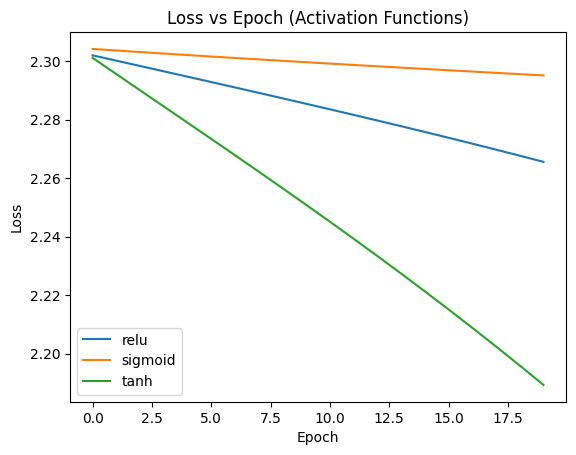

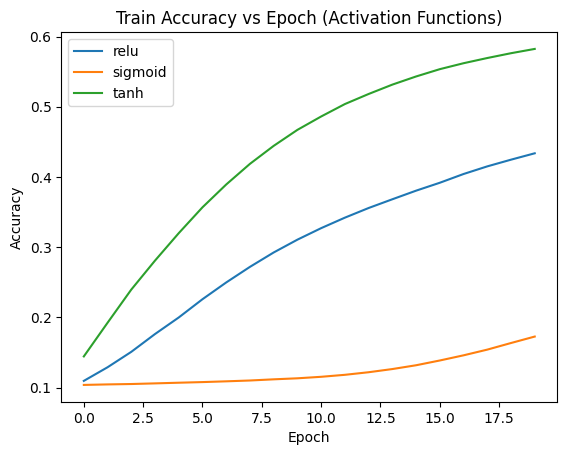

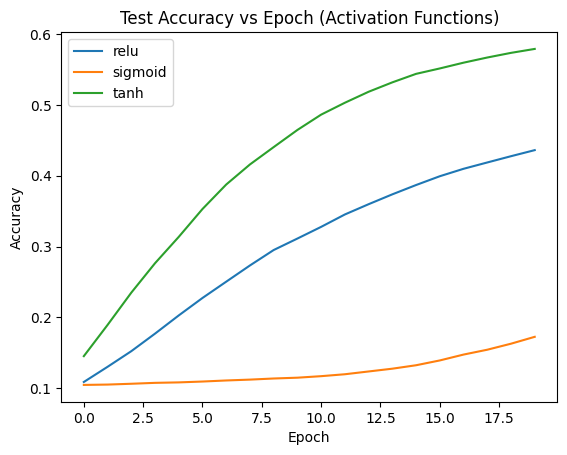

In [ ]:
# Plot Loss vs Epoch
for act in activations:
    plt.plot(results_act[act][0], label=act)

plt.title("Loss vs Epoch (Activation Functions)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


# Plot Train accuracy vs epoch
for act in activations:
    plt.plot(results_act[act][1], label=act)

plt.title("Train Accuracy vs Epoch (Activation Functions)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

#Plot Test accuracy vs epoch
for act in activations:
    plt.plot(results_act[act][2], label=act)

plt.title("Test Accuracy vs Epoch (Activation Functions)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

### Experiment 2: Learning Rate

The model is trained using different learning rates:
- 0.001  
- 0.01  
- 0.1  

All runs use ReLU activation.

The goal is to observe:
- Speed of convergence  
- Stability of training  
- Final performance


In [ ]:
# learning rates are different for comparision
learning_rates = [0.001, 0.01, 0.1]
results_lr = {}

for lr in learning_rates:
    model, losses, train_accs, test_accs = train(
        X_train, y_train, activation="relu", lr=lr, epochs=20
    )

    final_acc = accuracy(model, X_test, y_test)

    results_lr[lr] = (losses, train_accs, test_accs, final_acc)

    print(f"lr={lr} final accuracy: {final_acc:.4f}")

relu | lr=0.001 | epoch=1 | loss=2.2977
relu | lr=0.001 | epoch=2 | loss=2.2975
relu | lr=0.001 | epoch=3 | loss=2.2973
relu | lr=0.001 | epoch=4 | loss=2.2971
relu | lr=0.001 | epoch=5 | loss=2.2969
relu | lr=0.001 | epoch=6 | loss=2.2967
relu | lr=0.001 | epoch=7 | loss=2.2965
relu | lr=0.001 | epoch=8 | loss=2.2963
relu | lr=0.001 | epoch=9 | loss=2.2961
relu | lr=0.001 | epoch=10 | loss=2.2959
relu | lr=0.001 | epoch=11 | loss=2.2957
relu | lr=0.001 | epoch=12 | loss=2.2955
relu | lr=0.001 | epoch=13 | loss=2.2954
relu | lr=0.001 | epoch=14 | loss=2.2952
relu | lr=0.001 | epoch=15 | loss=2.2950
relu | lr=0.001 | epoch=16 | loss=2.2948
relu | lr=0.001 | epoch=17 | loss=2.2946
relu | lr=0.001 | epoch=18 | loss=2.2944
relu | lr=0.001 | epoch=19 | loss=2.2942
relu | lr=0.001 | epoch=20 | loss=2.2940
lr=0.001 final accuracy: 0.2189
relu | lr=0.01 | epoch=1 | loss=2.3017
relu | lr=0.01 | epoch=2 | loss=2.2998
relu | lr=0.01 | epoch=3 | loss=2.2978
relu | lr=0.01 | epoch=4 | loss=2.2959
r

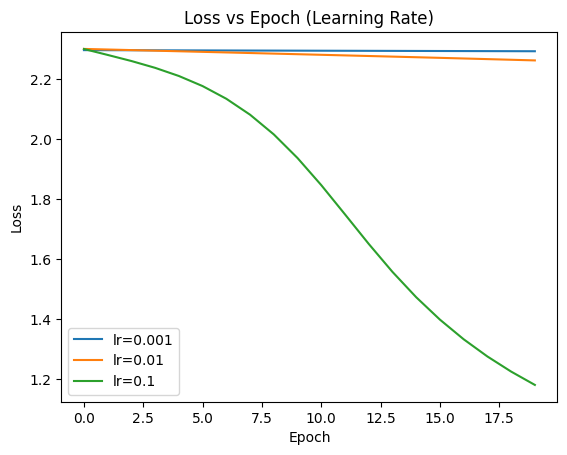

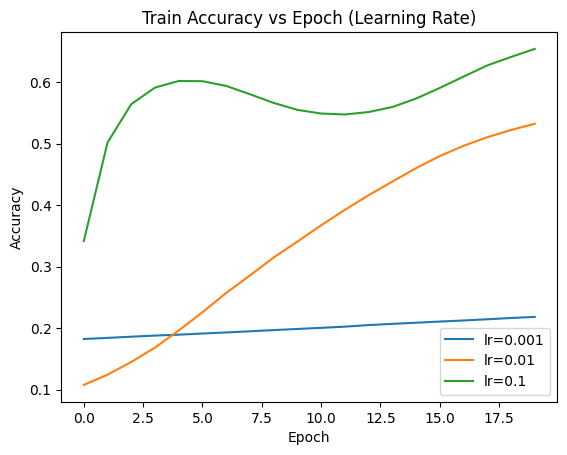

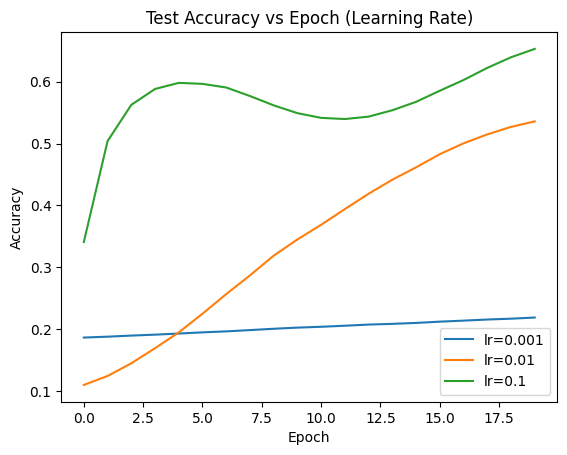

In [ ]:
# Plot learning rate loss

for lr in learning_rates:
    plt.plot(results_lr[lr][0], label=f"lr={lr}")

plt.title("Loss vs Epoch (Learning Rate)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Plot training accuracy vs epoch
for lr in learning_rates:
    plt.plot(results_lr[lr][1], label=f"lr={lr}")

plt.title("Train Accuracy vs Epoch (Learning Rate)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

#Plot testing accuracy vs epoch
for lr in learning_rates:
    plt.plot(results_lr[lr][2], label=f"lr={lr}")

plt.title("Test Accuracy vs Epoch (Learning Rate)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


## Results

### Loss vs Epoch (Activation Functions)
The loss curves show how quickly the model learns for each activation function.

Tanh shows the fastest decrease in loss.
ReLU shows a steady decrease.
Sigmoid decreases very slowly.

Accuracy (Activation Functions)
ReLU: 0.43
Sigmoid: 0.17
Tanh: 0.58

### Loss vs Epoch (Learning Rate)
Learning rate 0.001: very slow decrease in loss
Learning rate 0.01: smooth and steady decrease
Learning rate 0.1: fastest decrease in loss

### Accuracy (Learning Rate)
Accuracy (Learning Rate)
- 0.001: 0.2189
- 0.01: 0.5358
- 0.1: 0.6529

## Analysis & Discussion

### Activation Functions
- Tanh performs the best in this experiment, achieving the highest accuracy and fastest loss reduction.
- ReLU performs moderately well.
- Sigmoid performs poorly due to very slow learning and small gradient values.

### Learning Rate
Learning rate has a strong impact on model performance.

- A very small learning rate (0.001) results in slow learning and poor accuracy.
- A moderate learning rate (0.01) gives stable and reasonable performance.
- A higher learning rate (0.1) leads to faster convergence and the best accuracy in this case.

### Convergence Behavior
- The model converges fastest with learning rate 0.1.
- Lower learning rates take more time to converge.
- The loss curves are smooth because full batch gradient descent is used.



### General Observation
- The model is able to learn useful patterns even with a simple architecture.
- Both activation function and learning rate significantly affect performance.
- The model does not show overfitting, as training and test accuracy follow similar trends.

## Conclusion

- MLP can be successfully implemented from scratch using NumPy
- Tanh activation gives the best performance in this experiment
- ReLU performs moderately well, while Sigmoid performs poorly
- Learning rate strongly affects convergence and accuracy
- Higher learning rate (0.1) provides the best performance in this case
- Simple neural networks can still perform well on classification tasks

